In [8]:
print("hello world yo")

hello world yo


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [26]:
# Build correct paths (these point to your 'content' folder)
base_dir = os.getcwd()
face_cascade_path = os.path.join(base_dir, 'content', 'haarcascade_frontalface_default.xml')
eye_cascade_path = os.path.join(base_dir, 'content', 'haarcascade_eye.xml')

# Load the cascades
face_cascade = cv2.CascadeClassifier(face_cascade_path)
eye_cascade = cv2.CascadeClassifier(eye_cascade_path)

# Check if cascades loaded properly
if face_cascade.empty():
    raise IOError("Could not load face cascade. Check path.")
if eye_cascade.empty():
    raise IOError("Could not load eye cascade. Check path.")


In [20]:
ls content


andrew.jpg                           harr_casscade_classifiers/
haarcascade_eye.xml                  mercelis.jpeg
haarcascade_frontalface_default.xml


In [21]:
def adjusted_detect_face(img):
    face_img = img.copy()
    face_rect = face_cascade.detectMultiScale(face_img, scaleFactor=1.2, minNeighbors=5)

    for (x, y, w, h) in face_rect:
        cv2.rectangle(face_img, (x, y), (x + w, y + h), (255, 255, 255), 10)
        
    return face_img

In [22]:
def detect_eyes(img):
    eye_img = img.copy()
    eye_rect = eye_cascade.detectMultiScale(eye_img, scaleFactor=1.2, minNeighbors=5)

    for (x, y, w, h) in eye_rect:
        cv2.rectangle(eye_img, (x, y), (x + w, y + h), (255, 255, 255), 10)
        
    return eye_img

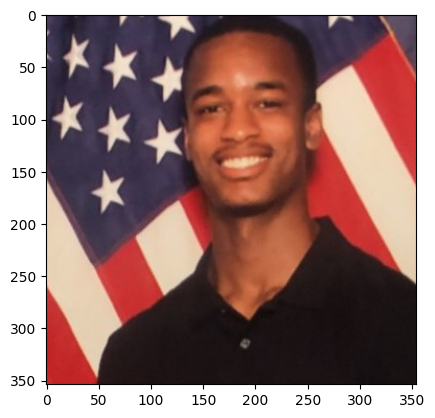

In [23]:
img = cv2.imread('content/mercelis.jpeg')
img_copy1 = img.copy()
img_copy2 = img.copy()
img_copy3 = img.copy()

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

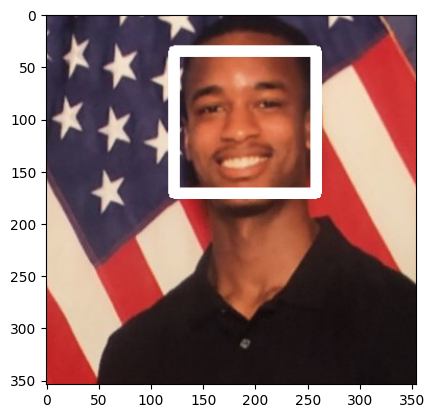

True

In [27]:
face = adjusted_detect_face(img_copy1)
plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
plt.show()
cv2.imwrite('face.jpg', face)

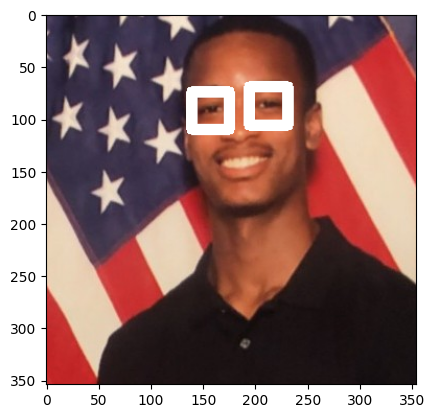

True

In [28]:
eyes = detect_eyes(img_copy2)
plt.imshow(cv2.cvtColor(eyes, cv2.COLOR_BGR2RGB))
plt.show()
cv2.imwrite('eyes.jpg', eyes)

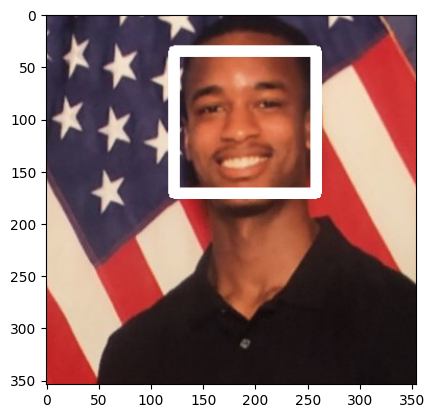

True

In [29]:
eyes_face = adjusted_detect_face(img_copy3)
plt.imshow(cv2.cvtColor(eyes_face, cv2.COLOR_BGR2RGB))
plt.show()
cv2.imwrite('face+eyes.jpg', eyes_face)

In [31]:
import time

In [32]:
start_time = time.time()
face = adjusted_detect_face(img_copy1)
face_time = time.time() - start_time
print(f"Face detection took {face_time:.4f} seconds")


start_time = time.time()
eyes = detect_eyes(img_copy2)
eye_time = time.time() - start_time
print(f"Eye detection took {eye_time:.4f} seconds")


start_time = time.time()
face_eyes = adjusted_detect_face(img_copy3)
eyes_face_time = time.time() - start_time
print(f"Face+Eyes detection took {eyes_face_time:.4f} seconds")


Face detection took 0.0086 seconds
Eye detection took 0.0085 seconds
Face+Eyes detection took 0.0080 seconds
